In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import sys
import warnings
sys.path.append("A2")
sys.path.append("preprocessing")
import regression_tree as rt
import random_forest as rf
import prediction_evaluation as eval
import grid_search
import parameter_eval
import preprocessing_food_wastage as pre_food_wastage
import preprocessing_college_ranking as pre_college_ranking
import preprocessing_popular_songs as pre_ppl_songs

pd.set_option("display.max_colwidth", None)

# Processing Datasets

Dataset Food Wastage
The full dataframe consists of 1782 rows, and 11 attributes
Rows containing NA values before preprocessing: 0


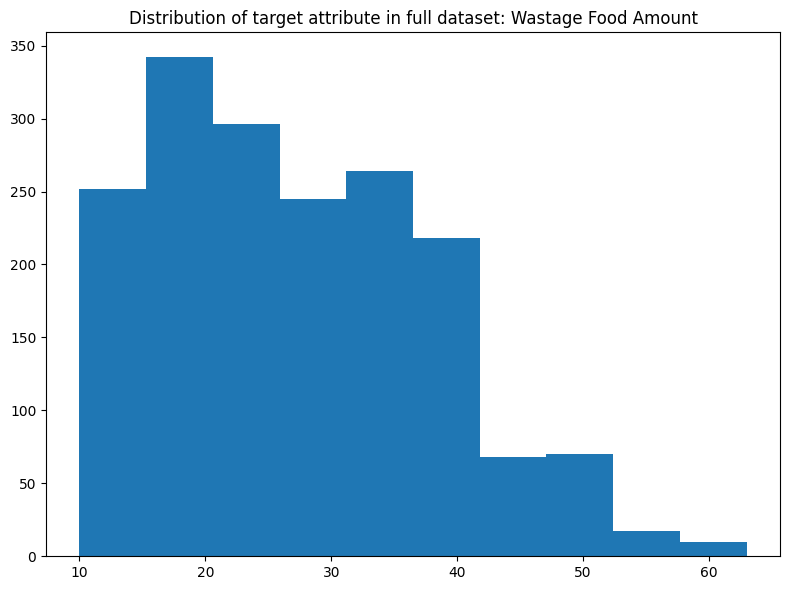

The train dataframe consists of 1188 rows, and 11 attributes


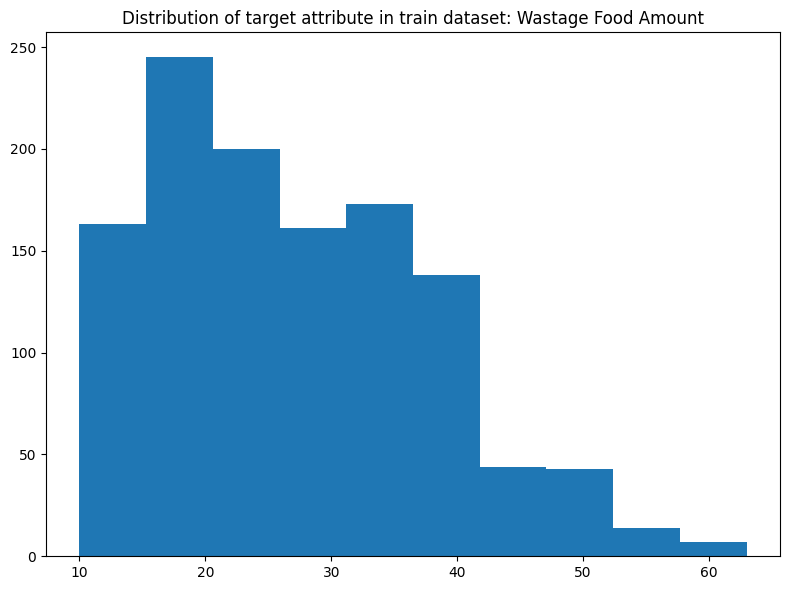

The test dataframe consists of 594 rows, and 11 attributes


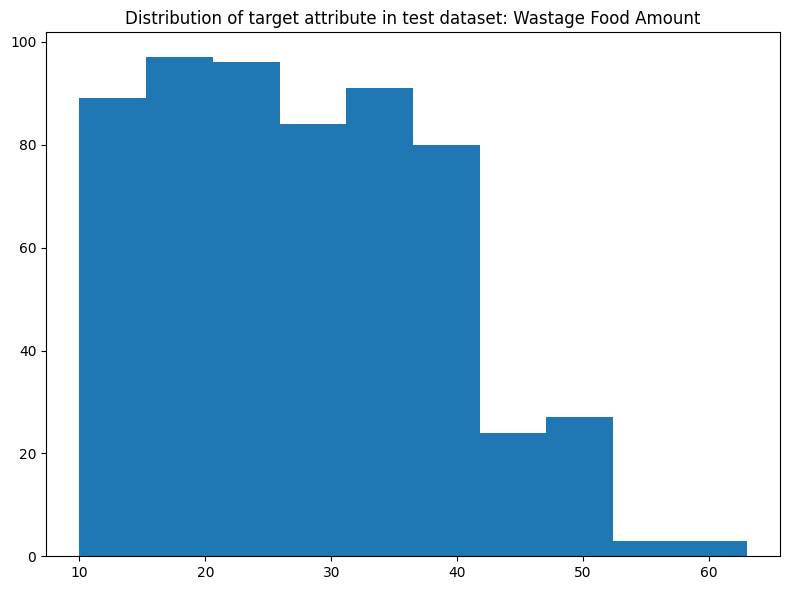

Dataset University Ranking
The full dataframe consists of 167 rows, and 41 attributes
Rows containing NA values before preprocessing: 160


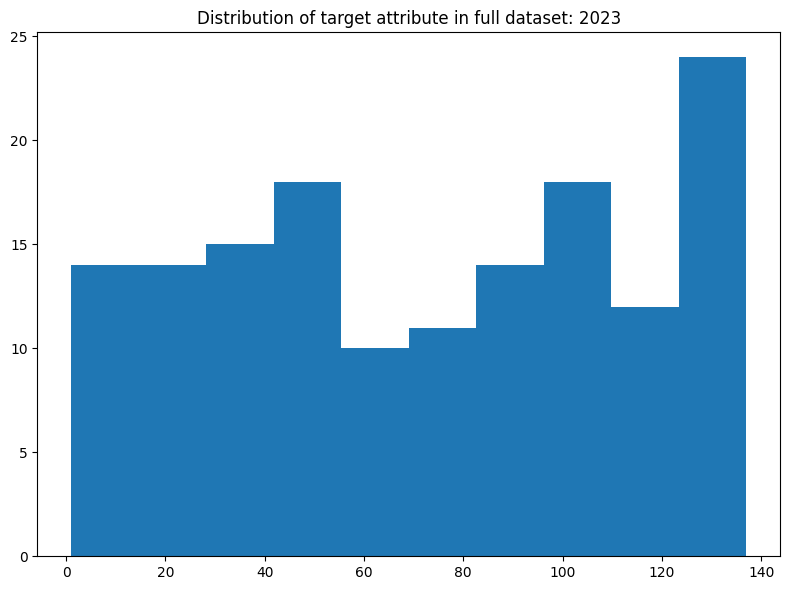

The train dataframe consists of 111 rows, and 41 attributes


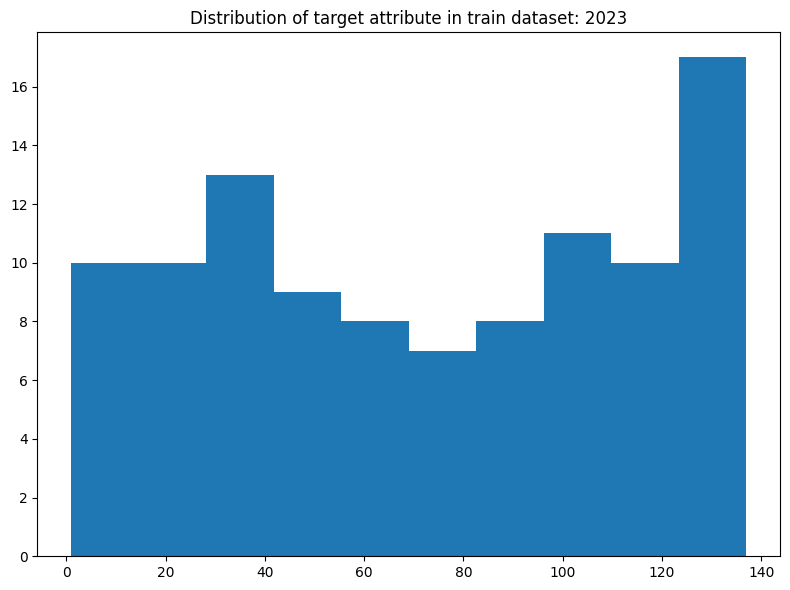

The test dataframe consists of 56 rows, and 41 attributes


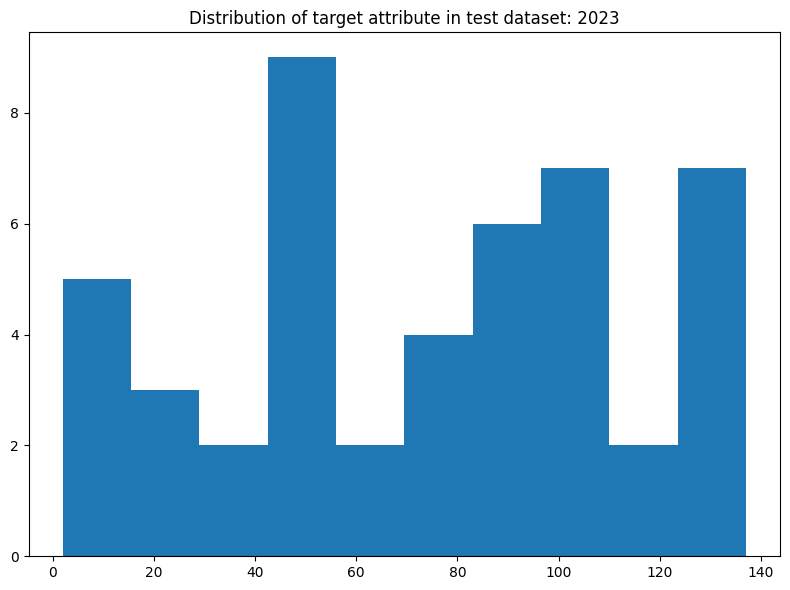

Null values count in the dataset 0
Categorical column "song_name" is at index:  0


In [3]:
warnings.filterwarnings('ignore', category=FutureWarning)

food_waste_df_train, food_waste_df_test = pre_food_wastage.preprocessing_food_wastage()
college_rank_df_train, college_rank_df_test = pre_college_ranking.preprocessing_college_ranking()
popular_songs_features_train, popular_songs_features_test = pre_ppl_songs.preprocessing_polar_songs()

# Paramater Grid

In [4]:
param_grid = {
    'min_samples_split': range(4,16,2),
    'max_depth': range(1,10,2),
    'split_criterion': ['mse', 'sse']
}


param_grid_scikit = {
    'min_samples_split': range(4,16,2),
    'max_depth': range(1,10,2),
    'criterion': ['squared_error']
}


param_grid_rf = {
    'no_of_estimators': range(10,100,20),
    'split_criterion': ['sse', 'mse'],
    'max_depth': range(1,3,1),
    'min_samples_split': range(5,7,1),
    'max_features_criterion': ['sqrt', 'log2']
}

param_grid_rf_scikit = {
    'n_estimators': range(10,100,20),
    'criterion': ['squared_error'],
    'max_depth': range(1,3,1),
    'min_samples_split': range(5,7,1),
    'max_features': ['sqrt', 'log2']
}


# Regression Trees

## Food Waste

### Our Implementation

In [5]:
best_tree_food_waste, train_results_food_waste = grid_search.grid_search_cv2(
    food_waste_df_train, "wastage_food_amount", rt.regression_tree, rt.predict_from_tree, param_grid)

train_results_food_waste.loc[:5,]

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:   14.8s
[Parallel(n_jobs=-1)]: Done  58 out of  60 | elapsed:  2.5min remaining:    5.1s
[Parallel(n_jobs=-1)]: Done  60 out of  60 | elapsed:  2.6min finished


,runtime,mean_rmse,mean_mae,Parameters
0,53.717207,3.245616,1.965447,"{'min_samples_split': 4, 'max_depth': 9, 'split_criterion': 'sse'}"
1,41.659988,3.291648,2.133965,"{'min_samples_split': 4, 'max_depth': 7, 'split_criterion': 'sse'}"
2,29.633952,3.540118,2.367919,"{'min_samples_split': 6, 'max_depth': 7, 'split_criterion': 'sse'}"
3,41.440038,3.579788,2.216228,"{'min_samples_split': 6, 'max_depth': 9, 'split_criterion': 'sse'}"
4,33.803817,3.649764,2.319824,"{'min_samples_split': 10, 'max_depth': 9, 'split_criterion': 'sse'}"
5,37.109627,3.744473,2.348050,"{'min_samples_split': 8, 'max_depth': 9, 'split_criterion': 'sse'}"


### Scikitlearn Implementation

In [6]:
train_results_food_waste_scikit, best_tree_scikit_food_waste = grid_search.grid_search_scikit(
    food_waste_df_train, "wastage_food_amount", param_grid_scikit)

train_results_food_waste_scikit.loc[:5,]

Fitting 5 folds for each of 30 candidates, totalling 150 fits
DecisionTreeRegressor(max_depth=9, min_samples_split=14, random_state=1)
Time(s):  1.710378625022713


,runtime,mean_rmse,mean_mae,Parameters
0,1.710379,3.202585,1.939226,"{'criterion': 'squared_error', 'max_depth': 9, 'min_samples_split': 14}"
1,1.710379,3.203612,1.914761,"{'criterion': 'squared_error', 'max_depth': 9, 'min_samples_split': 12}"
2,1.710379,3.213652,1.889940,"{'criterion': 'squared_error', 'max_depth': 9, 'min_samples_split': 10}"
3,1.710379,3.244165,1.879883,"{'criterion': 'squared_error', 'max_depth': 9, 'min_samples_split': 8}"
4,1.710379,3.286388,2.099310,"{'criterion': 'squared_error', 'max_depth': 7, 'min_samples_split': 6}"
5,1.710379,3.292443,2.100718,"{'criterion': 'squared_error', 'max_depth': 7, 'min_samples_split': 4}"


### Predictions on Test Set

In [7]:
# Our implementaiton
food_waste_predictions_on_test_reg_tree = rt.predict_from_tree(
    best_tree_food_waste, food_waste_df_test)

food_waste_rmse_on_test_reg_tree, food_waste_mae_on_test_reg_tree = eval.measure_predictions(
    food_waste_df_test["wastage_food_amount"], 
    food_waste_predictions_on_test_reg_tree)

print(f"Food waste score on test set using our own implementation. RMSE: {food_waste_rmse_on_test_reg_tree}, MAE: {food_waste_mae_on_test_reg_tree}")


# scikit-learn
food_waste_predictions_on_test_reg_tree_scikit = best_tree_scikit_food_waste.predict(
    food_waste_df_test.loc[:, food_waste_df_test.columns != "wastage_food_amount"])

food_waste_rmse_on_test_reg_tree_scikit, food_waste_mae_on_test_reg_tree_scikit = eval.measure_predictions(
    food_waste_df_test["wastage_food_amount"], 
    food_waste_predictions_on_test_reg_tree_scikit)

print(f"Food waste score on test set using Scikit implementation. RMSE: {food_waste_rmse_on_test_reg_tree_scikit}, MAE: {food_waste_mae_on_test_reg_tree_scikit}")

Food waste score on test set using our own implementation. RMSE: 3.165933858461153, MAE: 1.8682522966126551
Food waste score on test set using Scikit implementation. RMSE: 3.1985216148270506, MAE: 1.8731796309690238


## College Rank

### Our Implementation

In [ ]:
best_tree_college_rank, train_results_college_rank = grid_search.grid_search_cv2(
    college_rank_df_train, "2023", rt.regression_tree, rt.predict_from_tree, param_grid)

train_results_college_rank.loc[:5,]

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    2.5s
[Parallel(n_jobs=-1)]: Done  58 out of  60 | elapsed:   33.4s remaining:    1.2s
[Parallel(n_jobs=-1)]: Done  60 out of  60 | elapsed:   34.4s finished


,runtime,mean_rmse,mean_mae,Parameters
0,5.569128,9.163347,7.250029,"{'min_samples_split': 6, 'max_depth': 5, 'split_criterion': 'sse'}"
1,7.057432,9.431323,7.627979,"{'min_samples_split': 6, 'max_depth': 9, 'split_criterion': 'sse'}"
2,11.552453,9.558701,7.429894,"{'min_samples_split': 4, 'max_depth': 7, 'split_criterion': 'sse'}"
3,10.026269,10.013971,7.804180,"{'min_samples_split': 4, 'max_depth': 5, 'split_criterion': 'sse'}"
4,4.676408,10.113806,8.326743,"{'min_samples_split': 8, 'max_depth': 7, 'split_criterion': 'sse'}"
5,11.083692,10.132086,8.114519,"{'min_samples_split': 4, 'max_depth': 7, 'split_criterion': 'mse'}"


### Scikit-learn Implementation

In [ ]:
train_results_college_rank_scikit, best_tree_scikit_college_rank = grid_search.grid_search_scikit(
    college_rank_df_train, "2023", param_grid_scikit)

train_results_college_rank_scikit.loc[:5,]

Fitting 5 folds for each of 30 candidates, totalling 150 fits
DecisionTreeRegressor(max_depth=5, min_samples_split=8, random_state=1)
Time(s):  0.4991804590099491


,runtime,mean_rmse,mean_mae,Parameters
0,0.49918,9.962908,7.933744,"{'criterion': 'squared_error', 'max_depth': 5, 'min_samples_split': 8}"
1,0.49918,10.119857,8.261271,"{'criterion': 'squared_error', 'max_depth': 5, 'min_samples_split': 12}"
2,0.49918,10.159822,8.173889,"{'criterion': 'squared_error', 'max_depth': 5, 'min_samples_split': 10}"
3,0.49918,10.237771,8.173559,"{'criterion': 'squared_error', 'max_depth': 9, 'min_samples_split': 8}"
4,0.49918,10.254054,8.169620,"{'criterion': 'squared_error', 'max_depth': 7, 'min_samples_split': 8}"
5,0.49918,10.329612,8.328360,"{'criterion': 'squared_error', 'max_depth': 3, 'min_samples_split': 4}"


### Predictions on test set

In [10]:
# Our Implementation
college_rank_predictions_reg_tree = rt.predict_from_tree(
    best_tree_college_rank, 
    college_rank_df_test)

college_rank_rmse_on_test_reg_tree, college_rank_mae_on_test_reg_tree = eval.measure_predictions(
    college_rank_df_test["2023"], 
    college_rank_predictions_reg_tree)

print(f"College Rank scores on test set using our implementation. RMSE: {college_rank_rmse_on_test_reg_tree}, MAE: {college_rank_mae_on_test_reg_tree}")


# scikit_learn
college_rank_predictions_reg_tree_scikit = best_tree_scikit_college_rank.predict(
    college_rank_df_test.loc[:, college_rank_df_test.columns != "2023"])

college_rank_rmse_on_test_reg_tree_scikit, college_rank_mae_on_test_reg_tree_scikit = eval.measure_predictions(
    college_rank_df_test["2023"], 
    college_rank_predictions_reg_tree_scikit)

print(f"College Rank scores on test set using Scikit implementation. RMSE: {college_rank_rmse_on_test_reg_tree_scikit}, MAE: {college_rank_mae_on_test_reg_tree_scikit}")


College Rank scores on test set using our implementation. RMSE: 9.372216871445886, MAE: 7.542004225932797
College Rank scores on test set using Scikit implementation. RMSE: 10.103077791391781, MAE: 8.03844696969697


## Popular Songs

### Our Implementation

In [11]:
best_tree_popular_songs, train_results_popular_songs = grid_search.grid_search_cv2(
    popular_songs_features_train, "song_popularity", rt.regression_tree, rt.predict_from_tree, param_grid)
train_results_popular_songs.loc[:5,]

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:   34.1s
[Parallel(n_jobs=-1)]: Done  58 out of  60 | elapsed: 12.8min remaining:   26.5s
[Parallel(n_jobs=-1)]: Done  60 out of  60 | elapsed: 13.3min finished


,runtime,mean_rmse,mean_mae,Parameters
0,139.362447,21.086649,16.731115,"{'min_samples_split': 8, 'max_depth': 7, 'split_criterion': 'sse'}"
1,169.575273,21.149210,16.783103,"{'min_samples_split': 12, 'max_depth': 7, 'split_criterion': 'sse'}"
2,122.950418,21.158528,16.778776,"{'min_samples_split': 14, 'max_depth': 9, 'split_criterion': 'sse'}"
3,188.602719,21.179733,16.700239,"{'min_samples_split': 12, 'max_depth': 9, 'split_criterion': 'sse'}"
4,89.907791,21.222363,16.891923,"{'min_samples_split': 6, 'max_depth': 5, 'split_criterion': 'sse'}"
5,139.956678,21.238697,16.855954,"{'min_samples_split': 10, 'max_depth': 7, 'split_criterion': 'sse'}"


### Scikitlearn Implementation

In [12]:
train_results_popular_songs_scikit, best_tree_scikit_popular_songs = grid_search.grid_search_scikit(
    popular_songs_features_train, "song_popularity", param_grid_scikit)

train_results_popular_songs_scikit.loc[:5,]

Fitting 5 folds for each of 30 candidates, totalling 150 fits
DecisionTreeRegressor(max_depth=7, min_samples_split=6, random_state=1)
Time(s):  8.870842207979877


,runtime,mean_rmse,mean_mae,Parameters
0,8.870842,21.262442,16.853004,"{'criterion': 'squared_error', 'max_depth': 7, 'min_samples_split': 6}"
1,8.870842,21.270485,16.861474,"{'criterion': 'squared_error', 'max_depth': 7, 'min_samples_split': 10}"
2,8.870842,21.272384,16.860638,"{'criterion': 'squared_error', 'max_depth': 7, 'min_samples_split': 8}"
3,8.870842,21.273476,16.866812,"{'criterion': 'squared_error', 'max_depth': 7, 'min_samples_split': 12}"
4,8.870842,21.278135,16.860446,"{'criterion': 'squared_error', 'max_depth': 7, 'min_samples_split': 4}"
5,8.870842,21.280983,16.870418,"{'criterion': 'squared_error', 'max_depth': 7, 'min_samples_split': 14}"


### Predictions on Test Set

In [13]:
# Our Implementation
popular_songs_predictions_reg_tree = rt.predict_from_tree(
    best_tree_popular_songs, 
    popular_songs_features_test)

popular_songs_rmse_reg_tree, popular_songs_mae_reg_tree = eval.measure_predictions(
    popular_songs_features_test["song_popularity"], 
    popular_songs_predictions_reg_tree)

print(f"Popular Songs scores on test set using our implementation. RMSE:{popular_songs_rmse_reg_tree}, MAE:{popular_songs_mae_reg_tree}")


# scikit_learn
popular_songs_predictions_reg_tree_scikit = best_tree_scikit_popular_songs.predict(
    popular_songs_features_test.loc[:, popular_songs_features_test.columns != "song_popularity"])

popular_songs_rmse_reg_tree_scikit, popular_songs_mae_reg_tree_scikit = eval.measure_predictions(
    popular_songs_features_test["song_popularity"], 
    popular_songs_predictions_reg_tree_scikit)

print(f"Popular Songs scores on test set using Scikit implementation. RMSE{popular_songs_rmse_reg_tree_scikit}, MAE{popular_songs_mae_reg_tree_scikit}")

Popular Songs scores on test set using our implementation. RMSE:20.73343691530724, MAE:16.467516700615462
Popular Songs scores on test set using Scikit implementation. RMSE20.851354903578766, MAE16.517486213801998


# Random Forest

For Random forest, we do not need to use CV, because then we loose the OOB data for each bootstrap. So we do OOB eval instead with the same grid.

## Food Waste

### Our Implementation

In [14]:
best_forest_food_waste, train_results_rf_food_waste = grid_search.grid_search_oob(
    food_waste_df_train, "wastage_food_amount", param_grid_rf)

train_results_rf_food_waste.loc[:5,]

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    7.5s
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:   12.7s
[Parallel(n_jobs=-1)]: Done  16 tasks      | elapsed:   19.4s
[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed:   35.3s
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:   52.2s
[Parallel(n_jobs=-1)]: Done  45 tasks      | elapsed:  1.7min
[Parallel(n_jobs=-1)]: Done  56 tasks      | elapsed:  2.2min
[Parallel(n_jobs=-1)]: Done  74 out of  80 | elapsed:  3.6min remaining:   17.5s
[Parallel(n_jobs=-1)]: Done  80 out of  80 | elapsed:  4.0min finished


,runtime,mean_rmse,mean_mae,Parameters
0,42.323106,6.044478,4.596460,"{'no_of_estimators': 70, 'split_criterion': 'sse', 'max_depth': 2, 'min_samples_split': 6, 'max_features_criterion': 'log2'}"
1,29.748199,6.283429,4.843845,"{'no_of_estimators': 50, 'split_criterion': 'sse', 'max_depth': 2, 'min_samples_split': 6, 'max_features_criterion': 'log2'}"
2,29.595241,6.397973,4.797949,"{'no_of_estimators': 50, 'split_criterion': 'sse', 'max_depth': 2, 'min_samples_split': 5, 'max_features_criterion': 'sqrt'}"
3,15.089693,6.462847,4.913040,"{'no_of_estimators': 30, 'split_criterion': 'sse', 'max_depth': 2, 'min_samples_split': 6, 'max_features_criterion': 'log2'}"
4,42.973108,6.553416,5.074453,"{'no_of_estimators': 70, 'split_criterion': 'sse', 'max_depth': 2, 'min_samples_split': 5, 'max_features_criterion': 'log2'}"
5,42.431148,6.711381,5.146032,"{'no_of_estimators': 70, 'split_criterion': 'sse', 'max_depth': 2, 'min_samples_split': 5, 'max_features_criterion': 'sqrt'}"


### Scikit Implementation

In [15]:
train_results_rf_food_waste_scikit, best_forest_scikit_food_waste = grid_search.grid_search_oob_scikit(
    food_waste_df_train, "wastage_food_amount", param_grid_rf_scikit)

train_results_rf_food_waste_scikit.loc[:5,]

Running combo: 1 out of: 40
Running combo: 2 out of: 40
Running combo: 3 out of: 40
Running combo: 4 out of: 40
Running combo: 5 out of: 40
Running combo: 6 out of: 40
Running combo: 7 out of: 40


/Users/kartikarya/Library/CloudStorage/GoogleDrive-kartik.cs4030@rla.du.ac.in/My Drive/TU/S3/ML/Machine_learning_WS_2025/kml25/lib/python3.13/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/Users/kartikarya/Library/CloudStorage/GoogleDrive-kartik.cs4030@rla.du.ac.in/My Drive/TU/S3/ML/Machine_learning_WS_2025/kml25/lib/python3.13/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/Users/kartikarya/Library/CloudStorage/GoogleDrive-kartik.cs4030@rla.du.ac.in/My Drive/TU/S3/ML/Machine_learning_WS_2025/kml25/lib/python3.13/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/Users/kartik

Running combo: 8 out of: 40
Running combo: 9 out of: 40
Running combo: 10 out of: 40
Running combo: 11 out of: 40
Running combo: 12 out of: 40
Running combo: 13 out of: 40
Running combo: 14 out of: 40
Running combo: 15 out of: 40
Running combo: 16 out of: 40
Running combo: 17 out of: 40
Running combo: 18 out of: 40
Running combo: 19 out of: 40
Running combo: 20 out of: 40
Running combo: 21 out of: 40
Running combo: 22 out of: 40
Running combo: 23 out of: 40
Running combo: 24 out of: 40
Running combo: 25 out of: 40
Running combo: 26 out of: 40
Running combo: 27 out of: 40
Running combo: 28 out of: 40
Running combo: 29 out of: 40
Running combo: 30 out of: 40
Running combo: 31 out of: 40
Running combo: 32 out of: 40
Running combo: 33 out of: 40
Running combo: 34 out of: 40
Running combo: 35 out of: 40
Running combo: 36 out of: 40
Running combo: 37 out of: 40
Running combo: 38 out of: 40
Running combo: 39 out of: 40
Running combo: 40 out of: 40


,runtime,mean_rmse,mean_mse,Parameters
0,0.118337,7.397688,54.725791,"{'n_estimators': 90, 'criterion': 'squared_error', 'max_depth': 2, 'min_samples_split': 6, 'max_features': 'log2'}"
1,0.108284,7.397688,54.725791,"{'n_estimators': 90, 'criterion': 'squared_error', 'max_depth': 2, 'min_samples_split': 5, 'max_features': 'log2'}"
2,0.111557,7.397688,54.725791,"{'n_estimators': 90, 'criterion': 'squared_error', 'max_depth': 2, 'min_samples_split': 5, 'max_features': 'sqrt'}"
3,0.110999,7.397688,54.725791,"{'n_estimators': 90, 'criterion': 'squared_error', 'max_depth': 2, 'min_samples_split': 6, 'max_features': 'sqrt'}"
4,0.045631,7.441144,55.370620,"{'n_estimators': 30, 'criterion': 'squared_error', 'max_depth': 2, 'min_samples_split': 6, 'max_features': 'log2'}"
5,0.043432,7.441144,55.370620,"{'n_estimators': 30, 'criterion': 'squared_error', 'max_depth': 2, 'min_samples_split': 6, 'max_features': 'sqrt'}"


### Prediction on Test set

In [ ]:
# Our Implementation
food_waste_predictions_rf = rf.predict_from_forest(
    food_waste_df_test, best_forest_food_waste)

food_waste_rmse_rf, food_waste_mae_rf = eval.measure_predictions(
    food_waste_df_test["wastage_food_amount"], 
    food_waste_predictions_rf)

print(f"Food waste scores on test set using Our implementation. RMSE {food_waste_rmse_rf}, MAE {food_waste_mae_rf}")


# scikit-learn
food_waste_predictions_rf_scikit = best_forest_scikit_food_waste.predict(
    food_waste_df_test.loc[:, food_waste_df_test.columns != "wastage_food_amount"])

food_waste_rmse_rf_scikit, food_waste_mae_rf_scikit = eval.measure_predictions(
    food_waste_df_test["wastage_food_amount"], 
    food_waste_predictions_rf_scikit)

print(f"Food waste scores on test set using Scikit implementation. RMSE {food_waste_rmse_rf_scikit}, MAE {food_waste_mae_rf_scikit}")

Food waste scores on test set using Our implementation. RMSE6.057676361268466, MAE4.623450949494388
Food waste scores on test set using Scikit implementation. RMSE7.179940439147373, MAE5.546281529887989


## College Rank

### Our Implementation

In [17]:
best_forest_college_rank, train_results_rf_college_rank = grid_search.grid_search_oob(
    college_rank_df_train, "2023", param_grid_rf)

train_results_rf_college_rank.loc[:5,]

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    2.8s
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    4.1s
[Parallel(n_jobs=-1)]: Done  16 tasks      | elapsed:    7.6s
[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed:   13.5s
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:   19.4s
[Parallel(n_jobs=-1)]: Done  45 tasks      | elapsed:   28.5s
[Parallel(n_jobs=-1)]: Done  56 tasks      | elapsed:   37.0s
[Parallel(n_jobs=-1)]: Done  74 out of  80 | elapsed:   55.8s remaining:    4.5s
[Parallel(n_jobs=-1)]: Done  80 out of  80 | elapsed:  1.0min finished


,runtime,mean_rmse,mean_mae,Parameters
0,12.258610,15.300959,12.164430,"{'no_of_estimators': 90, 'split_criterion': 'sse', 'max_depth': 2, 'min_samples_split': 5, 'max_features_criterion': 'sqrt'}"
1,6.835007,15.603533,12.829577,"{'no_of_estimators': 50, 'split_criterion': 'sse', 'max_depth': 2, 'min_samples_split': 6, 'max_features_criterion': 'sqrt'}"
2,11.232000,15.841959,12.171404,"{'no_of_estimators': 70, 'split_criterion': 'sse', 'max_depth': 2, 'min_samples_split': 5, 'max_features_criterion': 'sqrt'}"
3,11.954975,15.982568,12.279795,"{'no_of_estimators': 90, 'split_criterion': 'sse', 'max_depth': 2, 'min_samples_split': 6, 'max_features_criterion': 'sqrt'}"
4,8.429117,16.103939,12.422327,"{'no_of_estimators': 30, 'split_criterion': 'sse', 'max_depth': 2, 'min_samples_split': 5, 'max_features_criterion': 'sqrt'}"
5,8.220887,16.164946,12.354507,"{'no_of_estimators': 70, 'split_criterion': 'mse', 'max_depth': 2, 'min_samples_split': 5, 'max_features_criterion': 'sqrt'}"


### Scikit Implmentation

In [18]:
train_results_rf_college_rank_scikit, best_forest_scikit_college_rank = grid_search.grid_search_oob_scikit(
    college_rank_df_train, "2023", param_grid_rf_scikit)

train_results_rf_college_rank_scikit.loc[:5,]

Running combo: 1 out of: 40
Running combo: 2 out of: 40
Running combo: 3 out of: 40
Running combo: 4 out of: 40
Running combo: 5 out of: 40
Running combo: 6 out of: 40
Running combo: 7 out of: 40
Running combo: 8 out of: 40
Running combo: 9 out of: 40
Running combo: 10 out of: 40
Running combo: 11 out of: 40
Running combo: 12 out of: 40
Running combo: 13 out of: 40
Running combo: 14 out of: 40
Running combo: 15 out of: 40
Running combo: 16 out of: 40
Running combo: 17 out of: 40
Running combo: 18 out of: 40
Running combo: 19 out of: 40
Running combo: 20 out of: 40
Running combo: 21 out of: 40
Running combo: 22 out of: 40
Running combo: 23 out of: 40
Running combo: 24 out of: 40
Running combo: 25 out of: 40
Running combo: 26 out of: 40
Running combo: 27 out of: 40
Running combo: 28 out of: 40
Running combo: 29 out of: 40
Running combo: 30 out of: 40
Running combo: 31 out of: 40
Running combo: 32 out of: 40
Running combo: 33 out of: 40
Running combo: 34 out of: 40
Running combo: 35 out o

,runtime,mean_rmse,mean_mse,Parameters
0,0.019312,14.568734,212.248016,"{'n_estimators': 10, 'criterion': 'squared_error', 'max_depth': 2, 'min_samples_split': 5, 'max_features': 'sqrt'}"
1,0.021818,14.568734,212.248016,"{'n_estimators': 10, 'criterion': 'squared_error', 'max_depth': 2, 'min_samples_split': 6, 'max_features': 'sqrt'}"
2,0.069086,14.684640,215.638644,"{'n_estimators': 70, 'criterion': 'squared_error', 'max_depth': 2, 'min_samples_split': 6, 'max_features': 'sqrt'}"
3,0.070321,14.684640,215.638644,"{'n_estimators': 70, 'criterion': 'squared_error', 'max_depth': 2, 'min_samples_split': 5, 'max_features': 'sqrt'}"
4,0.090893,14.716491,216.575107,"{'n_estimators': 90, 'criterion': 'squared_error', 'max_depth': 2, 'min_samples_split': 6, 'max_features': 'sqrt'}"
5,0.089124,14.716491,216.575107,"{'n_estimators': 90, 'criterion': 'squared_error', 'max_depth': 2, 'min_samples_split': 5, 'max_features': 'sqrt'}"


### Predictions on Test Set

In [ ]:
# Our Implementation
college_rank_predictions_rf = rf.predict_from_forest(
    college_rank_df_test, 
    best_forest_college_rank)

college_rank_rmse_rf, college_rank_mae_rf = eval.measure_predictions(
    college_rank_df_test["2023"], 
    college_rank_predictions_rf)

print(f"College Rank scores on test set using Our implementation. RMSE {college_rank_rmse_rf}, MAE {college_rank_mae_rf}")


# scikit-learn
college_rank_predictions_rf_scikit = best_forest_scikit_college_rank.predict(
    college_rank_df_test.loc[:, college_rank_df_test.columns != "2023"])

college_rank_rmse_rf_scikit, college_rank_mae_rf_scikit = eval.measure_predictions(
    college_rank_df_test["2023"], 
    college_rank_predictions_rf_scikit)

print(f"College Rank scores on test set using Our implementation. RMSE {college_rank_rmse_rf_scikit}, MAE {college_rank_mae_rf_scikit}")

College Rank scores on test set using Our implementation. RMSE14.682243579868311, MAE11.383735093503956
College Rank scores on test set using Our implementation. RMSE14.337483851154476, MAE11.326696913984145


## Popular Songs

### Our Implementation

In [22]:
best_forest_popular_songs, train_results_rf_popular_songs = grid_search.grid_search_oob(
    popular_songs_features_train, 
    "song_popularity", 
    param_grid_rf)

train_results_rf_popular_songs.loc[:5,]

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:   40.6s
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:  1.5min
[Parallel(n_jobs=-1)]: Done  16 tasks      | elapsed:  2.0min
[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed:  4.5min
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:  6.8min
[Parallel(n_jobs=-1)]: Done  45 tasks      | elapsed: 11.7min
[Parallel(n_jobs=-1)]: Done  56 tasks      | elapsed: 15.0min
[Parallel(n_jobs=-1)]: Done  74 out of  80 | elapsed: 25.1min remaining:  2.0min
[Parallel(n_jobs=-1)]: Done  80 out of  80 | elapsed: 28.0min finished


,runtime,mean_rmse,mean_mae,Parameters
0,62.166856,21.435422,17.092598,"{'no_of_estimators': 10, 'split_criterion': 'sse', 'max_depth': 2, 'min_samples_split': 6, 'max_features_criterion': 'sqrt'}"
1,67.999258,21.465524,17.104288,"{'no_of_estimators': 10, 'split_criterion': 'sse', 'max_depth': 2, 'min_samples_split': 5, 'max_features_criterion': 'sqrt'}"
2,64.613450,21.468867,17.114012,"{'no_of_estimators': 10, 'split_criterion': 'sse', 'max_depth': 2, 'min_samples_split': 5, 'max_features_criterion': 'log2'}"
3,62.877312,21.487236,17.124416,"{'no_of_estimators': 10, 'split_criterion': 'sse', 'max_depth': 2, 'min_samples_split': 6, 'max_features_criterion': 'log2'}"
4,249.958526,21.518970,17.107601,"{'no_of_estimators': 70, 'split_criterion': 'sse', 'max_depth': 2, 'min_samples_split': 6, 'max_features_criterion': 'sqrt'}"
5,276.539047,21.519456,17.124565,"{'no_of_estimators': 90, 'split_criterion': 'sse', 'max_depth': 2, 'min_samples_split': 5, 'max_features_criterion': 'sqrt'}"


### Scikit Implementation

In [23]:
train_results_rf_popular_songs_scikit, best_forest_scikit_popular_songs = grid_search.grid_search_oob_scikit(
    popular_songs_features_train, 
    "song_popularity", 
    param_grid_rf_scikit)

train_results_rf_popular_songs_scikit.loc[:5,]

Running combo: 1 out of: 40
Running combo: 2 out of: 40
Running combo: 3 out of: 40


/Users/kartikarya/Library/CloudStorage/GoogleDrive-kartik.cs4030@rla.du.ac.in/My Drive/TU/S3/ML/Machine_learning_WS_2025/kml25/lib/python3.13/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/Users/kartikarya/Library/CloudStorage/GoogleDrive-kartik.cs4030@rla.du.ac.in/My Drive/TU/S3/ML/Machine_learning_WS_2025/kml25/lib/python3.13/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/Users/kartikarya/Library/CloudStorage/GoogleDrive-kartik.cs4030@rla.du.ac.in/My Drive/TU/S3/ML/Machine_learning_WS_2025/kml25/lib/python3.13/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


Running combo: 4 out of: 40
Running combo: 5 out of: 40
Running combo: 6 out of: 40


/Users/kartikarya/Library/CloudStorage/GoogleDrive-kartik.cs4030@rla.du.ac.in/My Drive/TU/S3/ML/Machine_learning_WS_2025/kml25/lib/python3.13/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/Users/kartikarya/Library/CloudStorage/GoogleDrive-kartik.cs4030@rla.du.ac.in/My Drive/TU/S3/ML/Machine_learning_WS_2025/kml25/lib/python3.13/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/Users/kartikarya/Library/CloudStorage/GoogleDrive-kartik.cs4030@rla.du.ac.in/My Drive/TU/S3/ML/Machine_learning_WS_2025/kml25/lib/python3.13/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


Running combo: 7 out of: 40
Running combo: 8 out of: 40


/Users/kartikarya/Library/CloudStorage/GoogleDrive-kartik.cs4030@rla.du.ac.in/My Drive/TU/S3/ML/Machine_learning_WS_2025/kml25/lib/python3.13/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/Users/kartikarya/Library/CloudStorage/GoogleDrive-kartik.cs4030@rla.du.ac.in/My Drive/TU/S3/ML/Machine_learning_WS_2025/kml25/lib/python3.13/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


Running combo: 9 out of: 40
Running combo: 10 out of: 40
Running combo: 11 out of: 40
Running combo: 12 out of: 40
Running combo: 13 out of: 40
Running combo: 14 out of: 40
Running combo: 15 out of: 40
Running combo: 16 out of: 40
Running combo: 17 out of: 40
Running combo: 18 out of: 40
Running combo: 19 out of: 40
Running combo: 20 out of: 40
Running combo: 21 out of: 40
Running combo: 22 out of: 40
Running combo: 23 out of: 40
Running combo: 24 out of: 40
Running combo: 25 out of: 40
Running combo: 26 out of: 40
Running combo: 27 out of: 40
Running combo: 28 out of: 40
Running combo: 29 out of: 40
Running combo: 30 out of: 40
Running combo: 31 out of: 40
Running combo: 32 out of: 40
Running combo: 33 out of: 40
Running combo: 34 out of: 40
Running combo: 35 out of: 40
Running combo: 36 out of: 40
Running combo: 37 out of: 40
Running combo: 38 out of: 40
Running combo: 39 out of: 40
Running combo: 40 out of: 40


,runtime,mean_rmse,mean_mse,Parameters
0,0.237203,21.515707,462.925645,"{'n_estimators': 90, 'criterion': 'squared_error', 'max_depth': 2, 'min_samples_split': 6, 'max_features': 'log2'}"
1,0.270252,21.515707,462.925645,"{'n_estimators': 90, 'criterion': 'squared_error', 'max_depth': 2, 'min_samples_split': 5, 'max_features': 'sqrt'}"
2,0.277919,21.515707,462.925645,"{'n_estimators': 90, 'criterion': 'squared_error', 'max_depth': 2, 'min_samples_split': 6, 'max_features': 'sqrt'}"
3,0.284416,21.515707,462.925645,"{'n_estimators': 90, 'criterion': 'squared_error', 'max_depth': 2, 'min_samples_split': 5, 'max_features': 'log2'}"
4,0.094103,21.516357,462.953625,"{'n_estimators': 30, 'criterion': 'squared_error', 'max_depth': 2, 'min_samples_split': 6, 'max_features': 'log2'}"
5,0.106783,21.516357,462.953625,"{'n_estimators': 30, 'criterion': 'squared_error', 'max_depth': 2, 'min_samples_split': 6, 'max_features': 'sqrt'}"


### Predictions on test set

In [24]:
# Our Implementation
popular_songs_predictions_rf = rf.predict_from_forest(
    popular_songs_features_test, 
    best_forest_popular_songs)

popular_songs_rmse_rf, popular_songs_mae_rf = eval.measure_predictions(
    popular_songs_features_test["song_popularity"], 
    popular_songs_predictions_rf)

print(f"Popular Songs scores on test set using Our implementation. RMSE {popular_songs_rmse_rf}, MAE {popular_songs_mae_rf}")


# scikit-learn
popular_songs_predictions_rf_scikit = best_forest_scikit_popular_songs.predict(
    popular_songs_features_test.loc[:, popular_songs_features_test.columns != "song_popularity"])

popular_songs_rmse_rf_scikit, popular_songs_mae_rf_scikit = eval.measure_predictions(
    popular_songs_features_test["song_popularity"], 
    popular_songs_predictions_rf_scikit)

print(f"Popular Songs scores on test set using Scikit implementation. RMSE{popular_songs_rmse_rf_scikit}, MAE{popular_songs_mae_rf_scikit}")

Popular Songs scores on test set using Our implementation. RMSE 21.290924363744274, MAE 16.89417843003661
Popular Songs scores on test set using Scikit implementation. RMSE21.364916914433795, MAE16.948231533509446


# KNN

## Food Waste

In [25]:
food_waste_knn_model, food_waste_knn_runtime = grid_search.knn(food_waste_df_train, "wastage_food_amount")
food_waste_predictions_on_test_knn_scikit = food_waste_knn_model.predict(food_waste_df_test.loc[:, food_waste_df_test.columns != "wastage_food_amount"])
food_waste_rmse_on_test_knn_scikit, food_waste_mae_on_test_knn_scikit = eval.measure_predictions(food_waste_df_test["wastage_food_amount"], food_waste_predictions_on_test_reg_tree_scikit)

print(f"Food waste score on test set using Scikit KNN implementation. RMSE: {food_waste_rmse_on_test_knn_scikit}, MAE: {food_waste_mae_on_test_knn_scikit}")


food_waste_knn_results = {
    'runtime': food_waste_knn_runtime,
    'test set rmse': food_waste_rmse_on_test_knn_scikit,
    'test set mae': food_waste_mae_on_test_knn_scikit,
    'algorithm': "KNN",
    'dataset': "Food Wastage",
    'implementation': 'Scikit'
}


Food waste score on test set using Scikit KNN implementation. RMSE: 3.1985216148270506, MAE: 1.8731796309690238


## College Rank

In [26]:
college_rank_knn_model, college_rank_knn_runtime = grid_search.knn(college_rank_df_train, "2023")
college_rank_predictions_on_test_knn_scikit = college_rank_knn_model.predict(college_rank_df_test.loc[:, college_rank_df_test.columns != "2023"])
college_rank_rmse_on_test_knn_scikit, college_rank_mae_on_test_knn_scikit = eval.measure_predictions(college_rank_df_test["2023"], college_rank_predictions_on_test_knn_scikit)

print(f"University rank score on test set using Scikit KNN implementation. RMSE: {college_rank_rmse_on_test_knn_scikit}, MAE: {college_rank_mae_on_test_knn_scikit}")


college_rank_knn_results = {
    'runtime': college_rank_knn_runtime,
    'test set rmse': college_rank_rmse_on_test_knn_scikit,
    'test set mae': college_rank_mae_on_test_knn_scikit,
    'algorithm': "KNN",
    'dataset': "University Rank",
    'implementation': 'Scikit'
}


University rank score on test set using Scikit KNN implementation. RMSE: 11.764808297873547, MAE: 8.589285714285714


## Popular Songs

In [27]:
popular_songs_knn_model, popular_songs_knn_runtime = grid_search.knn(popular_songs_features_train, "song_popularity")
popular_songs_predictions_on_test_knn_scikit = popular_songs_knn_model.predict(popular_songs_features_test.loc[:, popular_songs_features_test.columns != "song_popularity"])
popular_songs_rmse_on_test_knn_scikit, popular_songs_mae_on_test_knn_scikit = eval.measure_predictions(popular_songs_features_test["song_popularity"], popular_songs_predictions_on_test_knn_scikit)

print(f"Popular Songs score on test set using Scikit KNN implementation. RMSE: {popular_songs_rmse_on_test_knn_scikit}, MAE: {popular_songs_mae_on_test_knn_scikit}")


popular_songs_knn_results = {
    'runtime': popular_songs_knn_runtime,
    'test set rmse': popular_songs_rmse_on_test_knn_scikit,
    'test set mae': popular_songs_mae_on_test_knn_scikit,
    'algorithm': "KNN",
    'dataset': "Popular Songs",
    'implementation': 'Scikit'
}


Popular Songs score on test set using Scikit KNN implementation. RMSE: 32.06528065740422, MAE: 24.653074227460976


# Hyperparameter Sensitivity Evaluation

## Regression Tree

0      4
1      4
2      6
3      6
4     10
5      8
6      8
7     12
8      4
9     10
10    12
11    14
12     8
13    12
14     6
15    10
16    14
17    14
18     8
19     6
20     4
21    10
22    14
23    12
24     4
25     6
26     4
27     4
28     4
29    10
30     8
31    14
32     8
33    14
34     6
35    10
36    12
37    14
38    14
39     8
40     6
41    12
42    12
43    10
44     8
45    12
46     6
47    10
48    14
49    12
50    10
51     8
52     4
53     6
54     8
55     4
56    14
57    12
58    10
59     6
Name: min_samples_split, dtype: int64


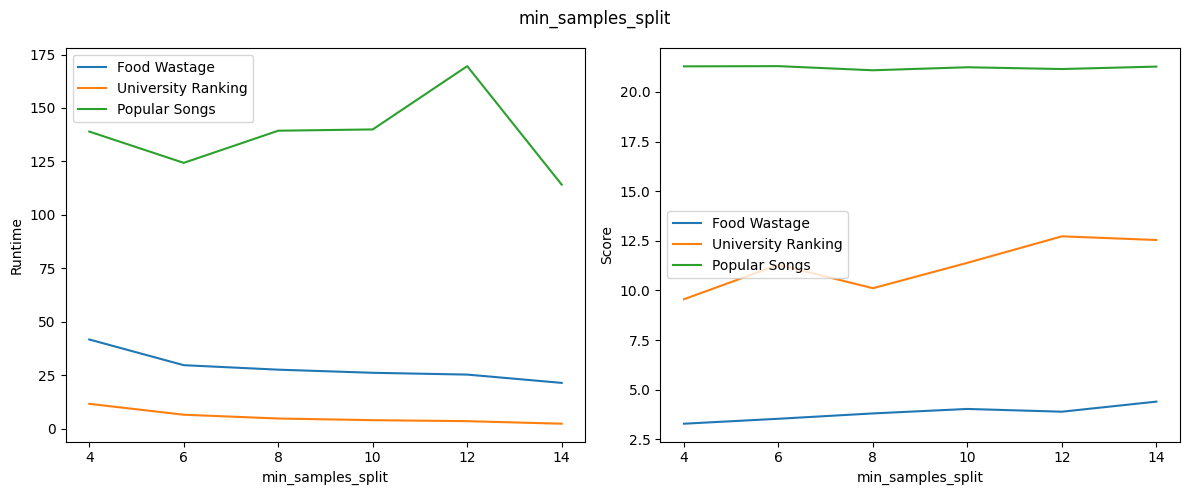

0     9
1     7
2     7
3     9
4     9
5     9
6     7
7     7
8     5
9     7
10    9
11    9
12    5
13    5
14    5
15    5
16    5
17    7
18    3
19    3
20    3
21    3
22    3
23    3
24    3
25    7
26    9
27    7
28    5
29    7
30    9
31    5
32    3
33    9
34    3
35    3
36    7
37    3
38    7
39    5
40    5
41    3
42    5
43    9
44    7
45    9
46    9
47    5
48    1
49    1
50    1
51    1
52    1
53    1
54    1
55    1
56    1
57    1
58    1
59    1
Name: max_depth, dtype: int64


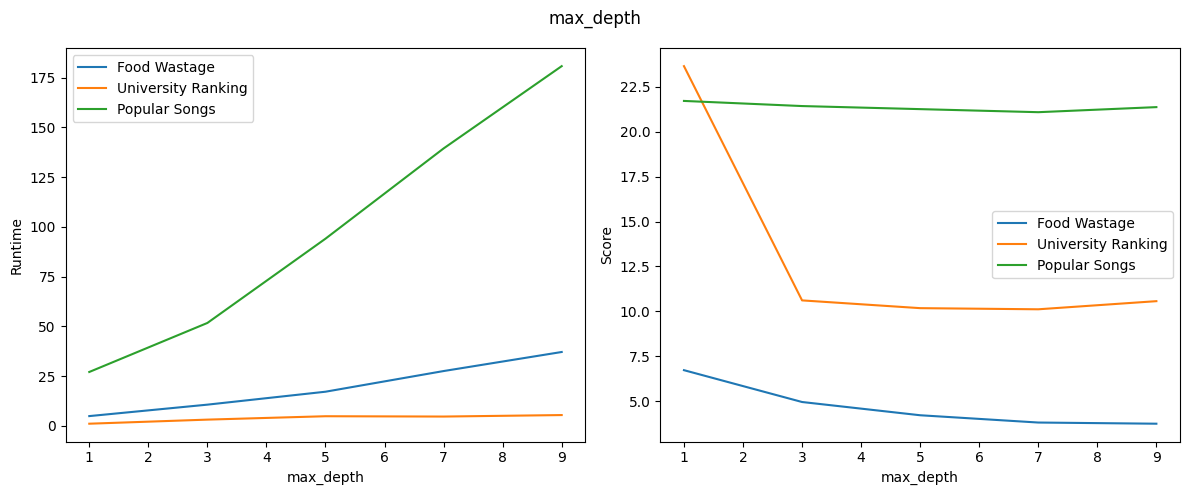

0     sse
1     sse
2     sse
3     sse
4     sse
5     sse
6     sse
7     sse
8     sse
9     sse
10    sse
11    sse
12    sse
13    sse
14    sse
15    sse
16    sse
17    sse
18    sse
19    sse
20    sse
21    sse
22    sse
23    sse
24    mse
25    mse
26    mse
27    mse
28    mse
29    mse
30    mse
31    mse
32    mse
33    mse
34    mse
35    mse
36    mse
37    mse
38    mse
39    mse
40    mse
41    mse
42    mse
43    mse
44    mse
45    mse
46    mse
47    mse
48    sse
49    sse
50    sse
51    sse
52    mse
53    mse
54    mse
55    sse
56    mse
57    mse
58    mse
59    sse
Name: split_criterion, dtype: object


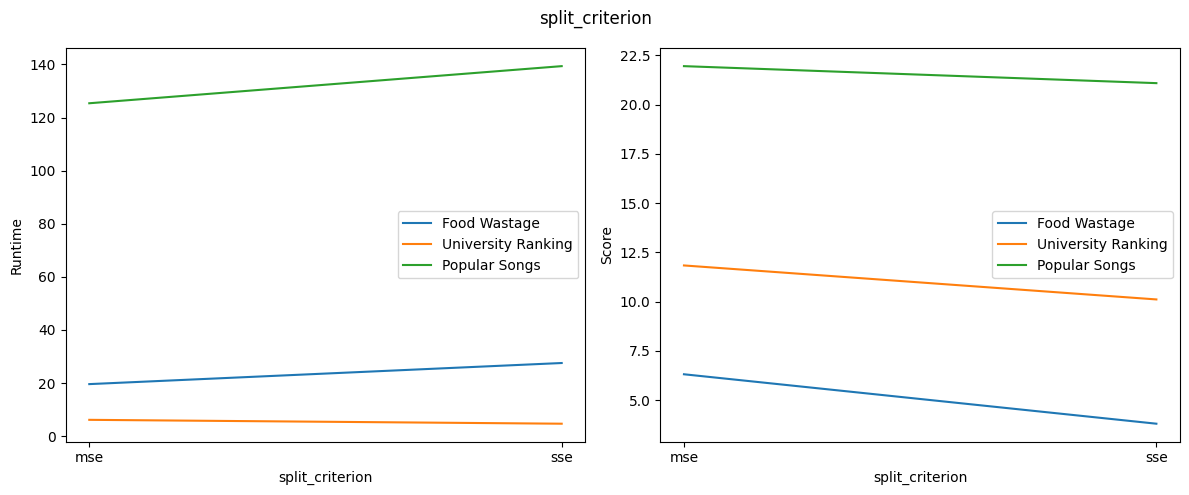

In [28]:
eval_param = {
    'min_samples_split': 8,
    'max_depth': 7,
    'split_criterion': 'sse'
}

parameter_eval.plot_parameter(train_results_food_waste, train_results_college_rank, train_results_popular_songs, param_grid, eval_param)

## Random Forest

0    70
1    50
2    50
3    30
4    70
5    70
Name: no_of_estimators, dtype: int64


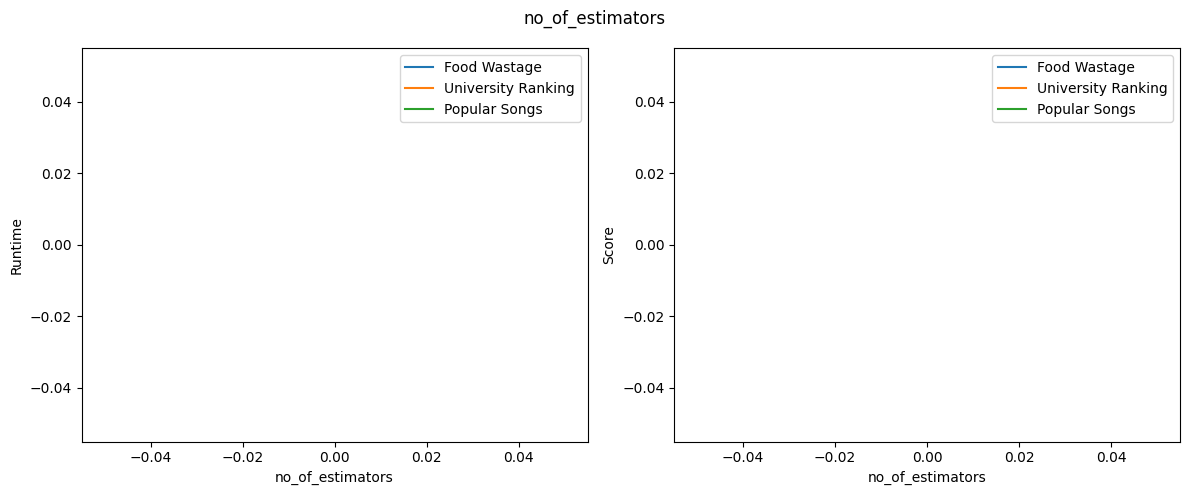

0    sse
1    sse
2    sse
3    sse
4    sse
5    sse
Name: split_criterion, dtype: object


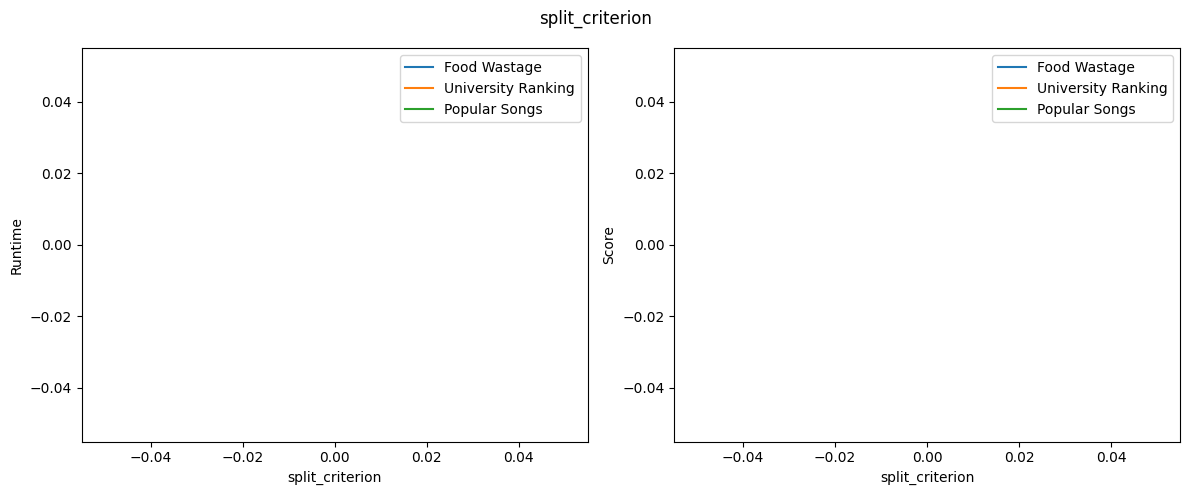

0    2
1    2
2    2
3    2
4    2
5    2
Name: max_depth, dtype: int64


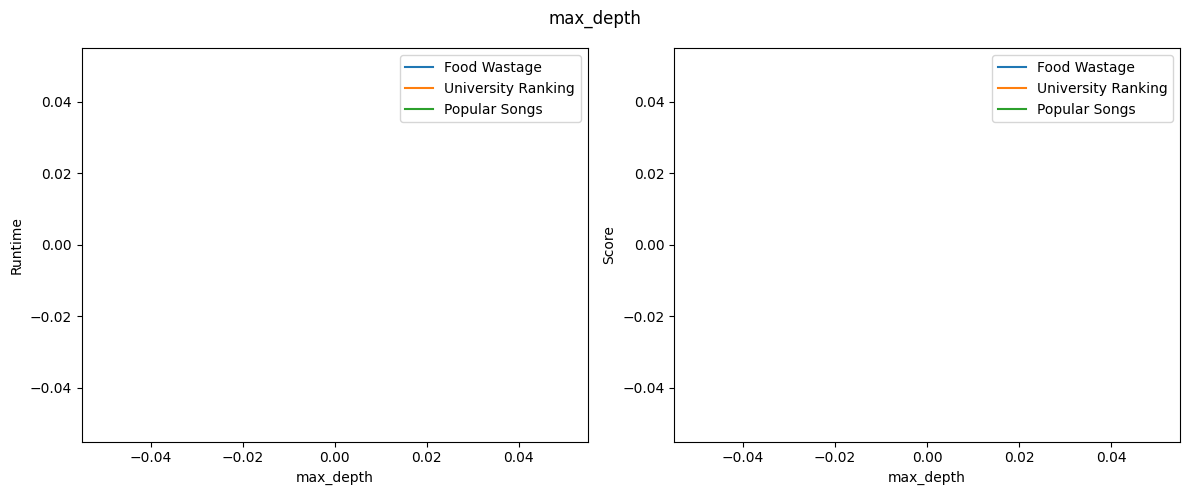

0    6
1    6
2    5
3    6
4    5
5    5
Name: min_samples_split, dtype: int64


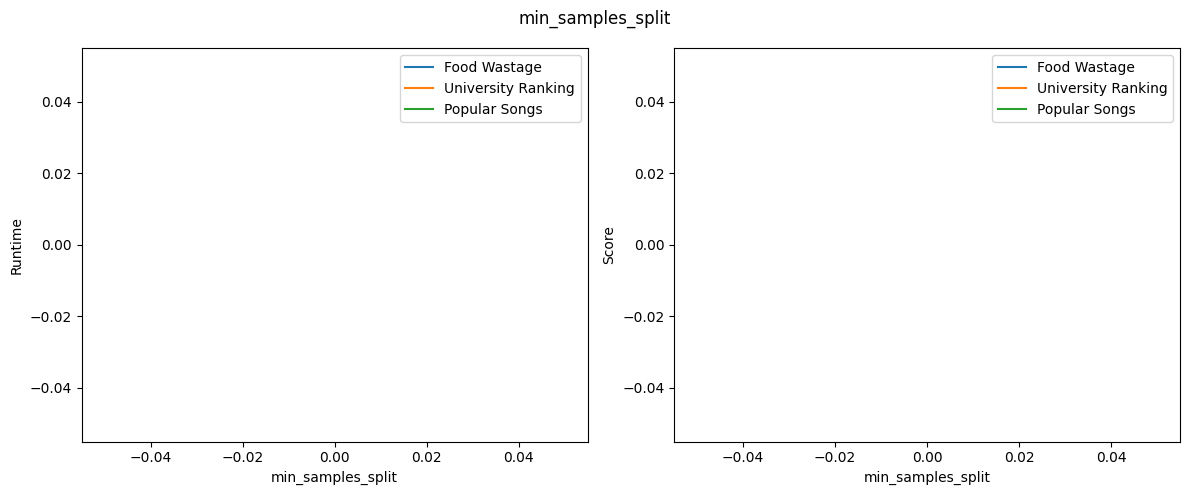

0    log2
1    log2
2    sqrt
3    log2
4    log2
5    sqrt
Name: max_features_criterion, dtype: object


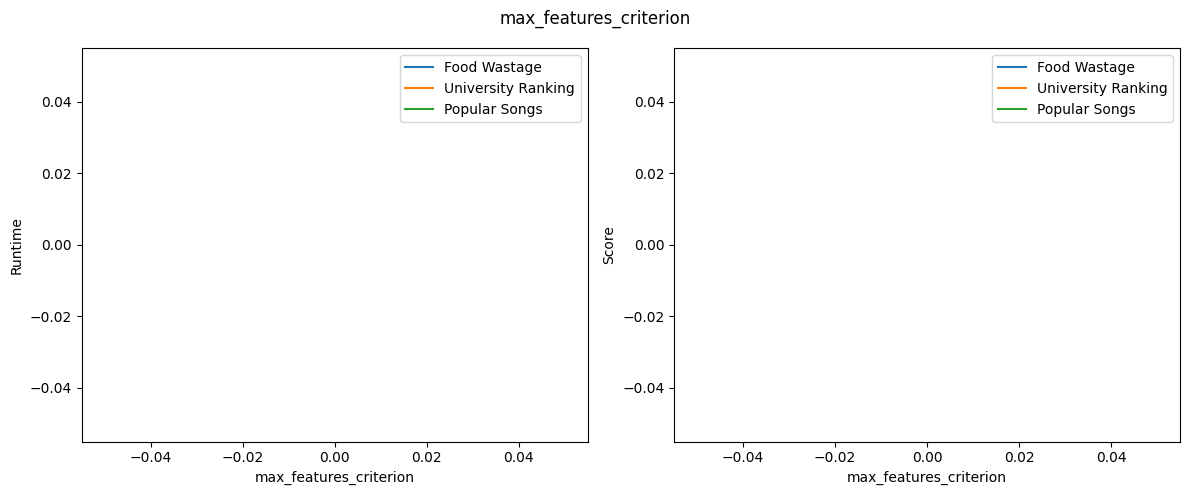

In [29]:
eval_param_rf = {
    'min_samples_split': 8,
    'max_depth': 7,
    'split_criterion': 'sse',
    'no_of_estimators': 50,
    'max_features_criterion': 'sqrt'
}

parameter_eval.plot_parameter(train_results_rf_food_waste, train_results_rf_college_rank, train_results_rf_popular_songs, param_grid_rf, eval_param_rf)

# Big Table

In [36]:
# TRAIN RESULTS
all_results = pd.concat([
    # Regression Tree
    train_results_food_waste.loc[[0]].assign(algorithm="Regression Tree", dataset="Food Wastage", implementation="Ours"),
    train_results_food_waste_scikit.loc[[0]].assign( algorithm="Regression Tree", dataset="Food Wastage", implementation="Scikit"),
    train_results_college_rank.loc[[0]].assign(algorithm="Regression Tree", dataset="University Rank", implementation="Ours"),
    train_results_college_rank_scikit.loc[[0]].assign( algorithm="Regression Tree", dataset="University Rank", implementation="Scikit"),
    train_results_popular_songs.loc[[0]].assign(algorithm="Regression Tree", dataset="Popular Songs", implementation="Ours"),
    train_results_popular_songs_scikit.loc[[0]].assign(algorithm="Regression Tree", dataset="Popular Songs", implementation="Scikit"),

    # Random Forest
    train_results_rf_food_waste.loc[[0]].assign(algorithm="Random Forest", dataset="Food Wastage", implementation="Ours"),
    train_results_rf_food_waste_scikit.loc[[0]].assign( algorithm="Random Forest", dataset="Food Wastage", implementation="Scikit"),
    train_results_rf_college_rank.loc[[0]].assign(algorithm="Random Forest", dataset="University Rank", implementation="Ours"),
    train_results_rf_college_rank_scikit.loc[[0]].assign( algorithm="Random Forest", dataset="University Rank", implementation="Scikit"),
    train_results_rf_popular_songs.loc[[0]].assign(algorithm="Random Forest", dataset="Popular Songs", implementation="Ours"),
    train_results_rf_popular_songs_scikit.loc[[0]].assign(algorithm="Random Forest", dataset="Popular Songs", implementation="Scikit")
    
]).reset_index(drop=True)
all_results = all_results.join(all_results['Parameters'].apply(pd.Series))

index_to_fix = ~all_results["criterion"].isna()
all_results.loc[index_to_fix, "split_criterion"] = all_results.loc[index_to_fix, "criterion"]

all_results = all_results.drop(["Parameters", "criterion"], axis=1)
all_results = all_results.rename(columns={'mean_rmse':'cross validated rmse', 'mean_mae': "cross validated mae"})


# PREDCTIONS
# Regression Tree
all_results = eval.big_table_formating(
    "Food Wastage", 
    all_results,
    
    food_waste_rmse_on_test_reg_tree,
    food_waste_mae_on_test_reg_tree,
    food_waste_rmse_on_test_reg_tree_scikit,
    food_waste_mae_on_test_reg_tree_scikit
)

all_results = eval.big_table_formating(
    "University Rank", 
    all_results,
    college_rank_rmse_on_test_reg_tree,
    college_rank_mae_on_test_reg_tree,
    college_rank_rmse_on_test_reg_tree_scikit,
    college_rank_mae_on_test_reg_tree_scikit
)
    
all_results = eval.big_table_formating(
    "Popular Songs", 
    all_results,
    popular_songs_rmse_reg_tree,
    popular_songs_mae_reg_tree,
    popular_songs_rmse_reg_tree_scikit,
    popular_songs_mae_reg_tree_scikit
)


# Random Forest
all_results = eval.big_table_formating(
    "Food Wastage", 
    all_results,
    food_waste_rmse_rf,
    food_waste_mae_rf,
    food_waste_rmse_rf_scikit,
    food_waste_mae_rf_scikit
    
)

all_results = eval.big_table_formating(
    "University Rank", 
    all_results,
    college_rank_rmse_rf,
    college_rank_mae_rf,
    college_rank_rmse_rf_scikit,
    college_rank_mae_rf_scikit,
)

all_results = eval.big_table_formating(
    "Popular Songs", 
    all_results,
    popular_songs_rmse_rf,
    popular_songs_mae_rf,
    popular_songs_rmse_rf_scikit,
    popular_songs_mae_rf_scikit,
)
all_results = pd.concat([all_results, pd.DataFrame([food_waste_knn_results, college_rank_knn_results, popular_songs_knn_results])], ignore_index=True)

all_results_reorderd = all_results[["algorithm", "dataset", "implementation", "runtime", "min_samples_split", "max_depth", "split_criterion", "cross validated rmse", "cross validated mae", "test set rmse", "test set mae"]]

all_results_reorderd

,algorithm,dataset,implementation,runtime,min_samples_split,max_depth,split_criterion,cross validated rmse,cross validated mae,test set rmse,test set mae
0,Regression Tree,Food Wastage,Ours,53.717207,4.0,9.0,sse,3.245616,1.965447,6.057676,4.623451
1,Regression Tree,Food Wastage,Scikit,1.710379,14.0,9.0,squared_error,3.202585,1.939226,7.179940,5.546282
2,Regression Tree,University Rank,Ours,5.569128,6.0,5.0,sse,9.163347,7.250029,14.682244,11.383735
3,Regression Tree,University Rank,Scikit,0.499180,8.0,5.0,squared_error,9.962908,7.933744,14.337484,11.326697
4,Regression Tree,Popular Songs,Ours,139.362447,8.0,7.0,sse,21.086649,16.731115,21.290924,16.894178
5,Regression Tree,Popular Songs,Scikit,8.870842,6.0,7.0,squared_error,21.262442,16.853004,21.364917,16.948232
6,Random Forest,Food Wastage,Ours,42.323106,6.0,2.0,sse,6.044478,4.596460,6.057676,4.623451
7,Random Forest,Food Wastage,Scikit,0.118337,6.0,2.0,squared_error,7.397688,NaN,7.179940,5.546282
8,Random Forest,University Rank,Ours,12.258610,5.0,2.0,sse,15.300959,12.164430,14.682244,11.383735
9,Random Forest,University Rank,Scikit,0.019312,5.0,2.0,squared_error,14.568734,NaN,14.337484,11.326697
